In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Converting Churn values and TotalCharges to numeric values 

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn'] = df['Churn'].astype(str).str.strip()
df['Churn'] = df['Churn'].replace({
    'Yes': 1,
    'No': 0
})
df['Churn'] = df['Churn'].astype(int)

C:\Users\Hp\AppData\Local\Temp\ipykernel_8276\3467773115.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({


# Distribution of Churn

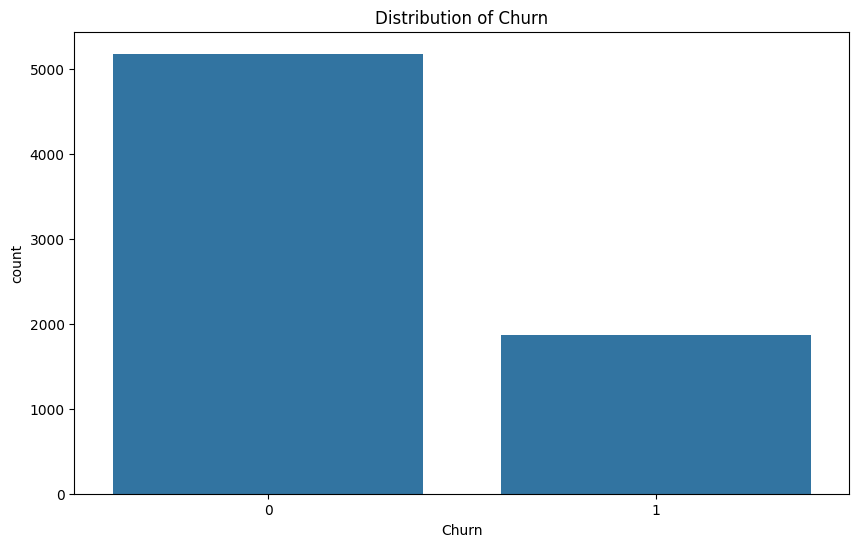

In [4]:
plt.figure(figsize=(10,6))
sns.countplot(x='Churn',data=df)
plt.title('Distribution of Churn')
plt.show()


# Churn Vs Tenure Group

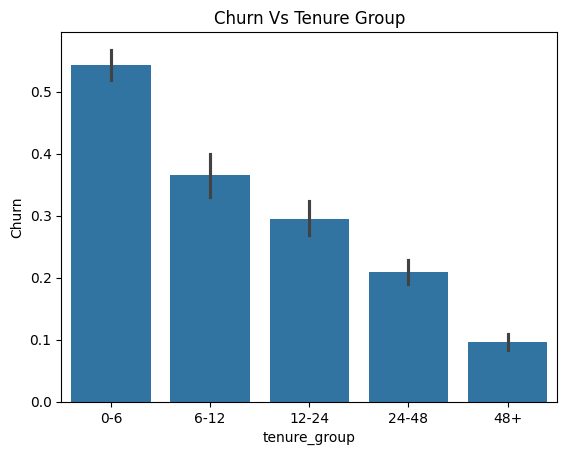

In [5]:
bins =[0,6,12,24,48,100]
labels = ['0-6','6-12','12-24','24-48','48+']
df["tenure_group"]=pd.cut(df["tenure"],bins=bins,labels=labels,right=False)
plt.figure()
sns.barplot(x="tenure_group",y="Churn",data=df)
plt.title("Churn Vs Tenure Group")
plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

# Billing Error Impact (if value difference is more than 5 dollars)

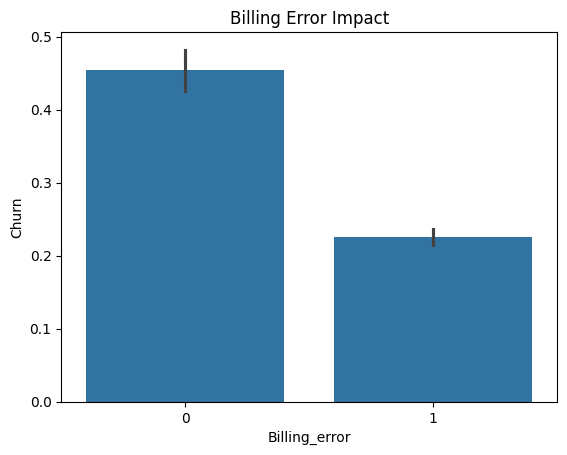

In [7]:
df["ExpectedTotal"]=df["MonthlyCharges"]*df["tenure"]
df["Billing_error"] = (abs(df["TotalCharges"] - df["ExpectedTotal"]))
df["Billing_error"]=(df["Billing_error"]>5).astype(int)
plt.figure()
sns.barplot(x="Billing_error",y="Churn",data=df)
plt.title("Billing Error Impact")
plt.show()


# Services Used Vs Churn

C:\Users\Hp\AppData\Local\Temp\ipykernel_8276\2270029396.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col]=df[col].replace({"Yes":1,"No":0,"No internet service":0})


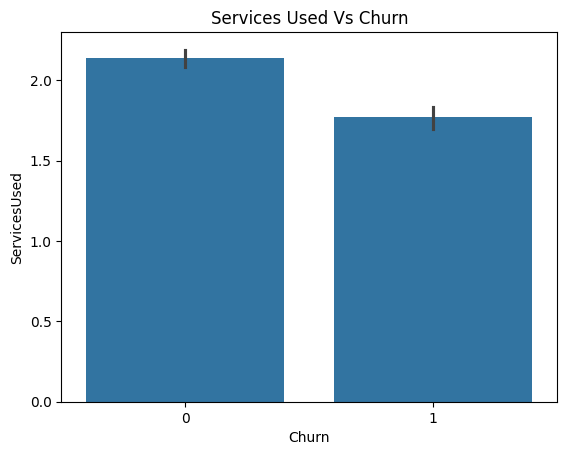

In [8]:
services=["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
for col in services:
    df[col]=df[col].replace({"Yes":1,"No":0,"No internet service":0})
df["ServicesUsed"]=df[services].sum(axis=1)
plt.figure()
sns.barplot(x="Churn",y="ServicesUsed",data=df)
plt.title("Services Used Vs Churn")
plt.show()   

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,ExpectedTotal,Billing_error,ServicesUsed
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,0,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6,29.85,0,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,1,...,One year,No,Mailed check,56.95,1889.50,0,24-48,1936.30,1,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,1,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6,107.70,0,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,1,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-48,1903.50,1,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,0,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-6,141.40,1,0


**why to use error more than five dollars ?**

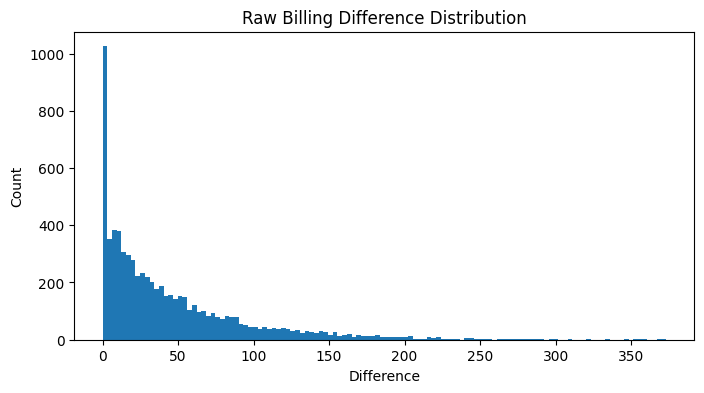

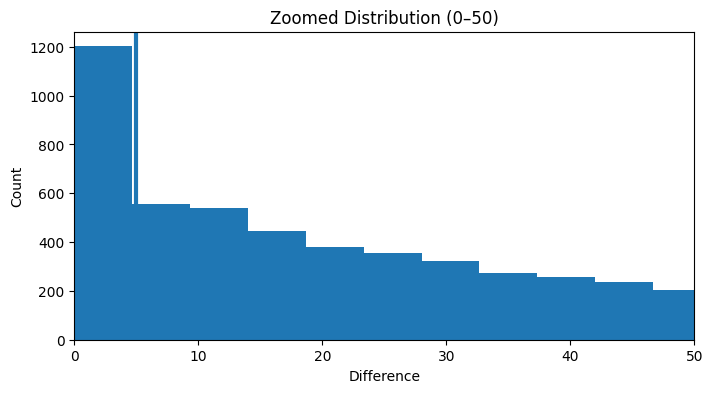

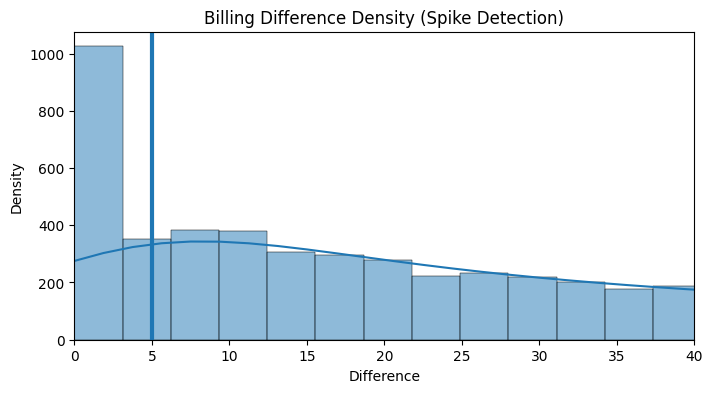

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

diff = abs(df['TotalCharges'] - df['MonthlyCharges']*df['tenure'])
plt.figure(figsize=(8,4))
plt.hist(diff, bins=120)
plt.title("Raw Billing Difference Distribution")
plt.xlabel("Difference")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(8,4))
plt.hist(diff, bins=80)
plt.xlim(0,50)
plt.axvline(5, linewidth=3)
plt.title("Zoomed Distribution (0–50)")
plt.xlabel("Difference")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(8,4))
sns.histplot(diff, bins=120, kde=True)
plt.xlim(0,40)
plt.axvline(5, linewidth=3)
plt.title("Billing Difference Density (Spike Detection)")
plt.xlabel("Difference")
plt.ylabel("Density")
plt.show()

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,ExpectedTotal,Billing_error,ServicesUsed
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,0,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6,29.85,0,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,1,...,One year,No,Mailed check,56.95,1889.50,0,24-48,1936.30,1,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,1,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6,107.70,0,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,1,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-48,1903.50,1,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,0,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-6,141.40,1,0


# Cost Pressure vs Churn

0       56.150
1       56.150
2       56.150
3       56.150
4       91.675
         ...  
7038    56.150
7039    91.675
7040    56.150
7041    91.675
7042    91.675
Name: MonthlyCharges, Length: 7043, dtype: float64


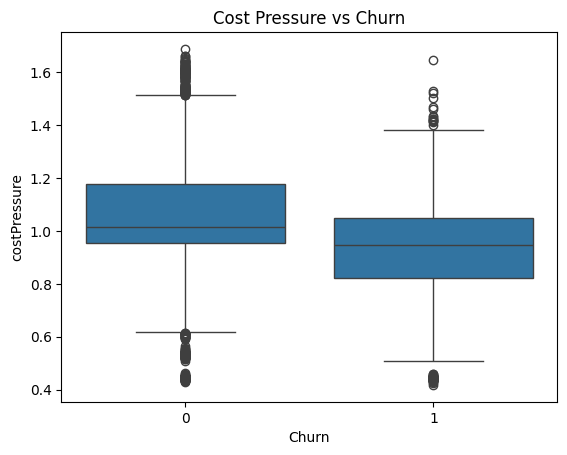

In [12]:
median_cost=(df.groupby("InternetService")["MonthlyCharges"].transform("median"))
print(median_cost)
df["costPressure"]=(df["MonthlyCharges"]/median_cost)
plt.figure()
sns.boxplot(x="Churn",y="costPressure",data=df)
plt.title("Cost Pressure vs Churn")
plt.show()

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,ExpectedTotal,Billing_error,ServicesUsed,costPressure
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,0,...,Yes,Electronic check,29.85,29.85,0,0-6,29.85,0,1,0.531612
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,1,...,No,Mailed check,56.95,1889.50,0,24-48,1936.30,1,2,1.014248
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,1,...,Yes,Mailed check,53.85,108.15,1,0-6,107.70,0,2,0.959038
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,1,...,No,Bank transfer (automatic),42.30,1840.75,0,24-48,1903.50,1,3,0.753339
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,0,...,Yes,Electronic check,70.70,151.65,1,0-6,141.40,1,0,0.771203


# Churn vs Family Score

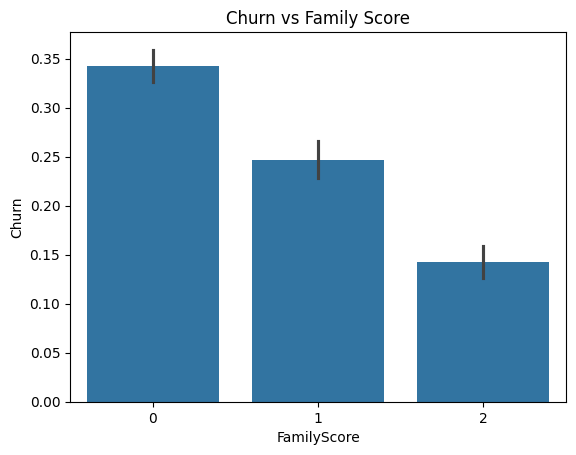

In [14]:
df["Partner"]=df["Partner"].map({"Yes":1,"No":0})
df["Dependents"]=df["Dependents"].map({"Yes":1,"No":0})
df["FamilyScore"]=df["Partner"]+df["Dependents"]
plt.figure()
sns.barplot(x="FamilyScore",y="Churn",data=df)
plt.title("Churn vs Family Score")
plt.show()

# Early Churn Risk vs Churn

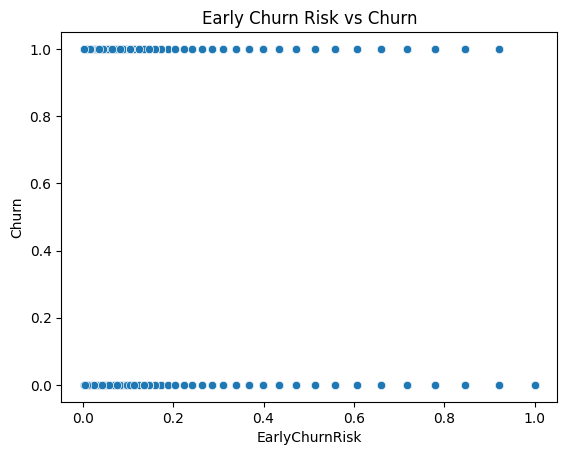

In [15]:
df["EarlyChurnRisk"] =  np.exp(-df['tenure'] / 12)
plt.figure()
sns.scatterplot(y="Churn",x="EarlyChurnRisk",data=df)
plt.title("Early Churn Risk vs Churn")
plt.show()

# Streaming User vs Churn

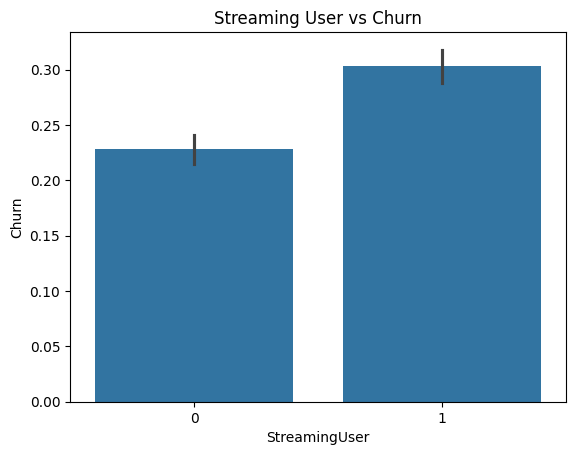

In [16]:
df["StreamingUser"] = ((df["StreamingTV"]+ df["StreamingMovies"]>0).astype(int))
plt.figure()
sns.barplot(x="StreamingUser",y="Churn",data=df)
plt.title("Streaming User vs Churn")
plt.show()

# Customer Frustration vs Churn

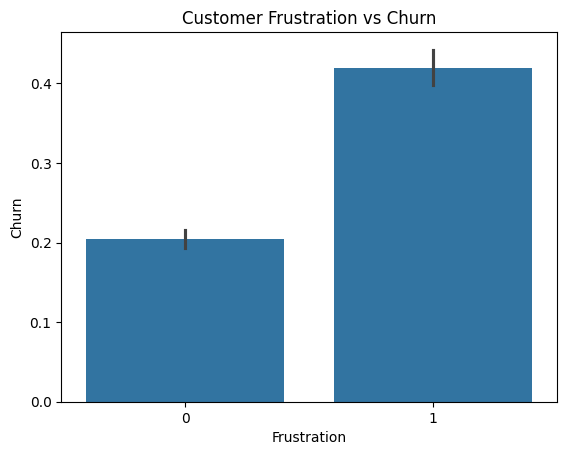

In [17]:
df['Frustration'] = ((df['StreamingUser'] == 1) & (df['TechSupport'] == 0)).astype(int)
plt.figure()
sns.barplot(x='Frustration', y='Churn', data=df)
plt.title('Customer Frustration vs Churn')
plt.show()


# Monthly Charges vs Churn

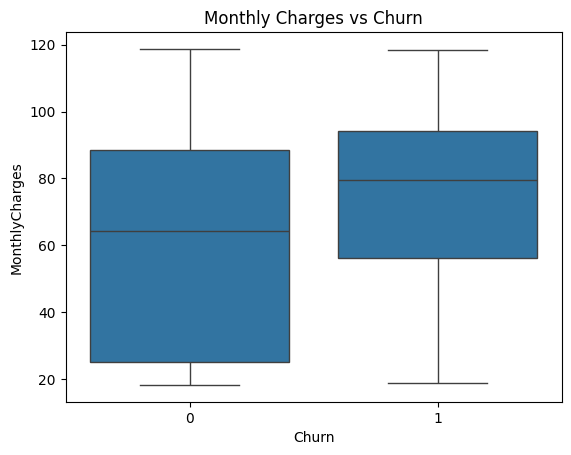

In [18]:
plt.figure()
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Churn')
plt.show()

# Payment Method vs Churn

Text(0.5, 1.0, 'Payment Method vs Churn')

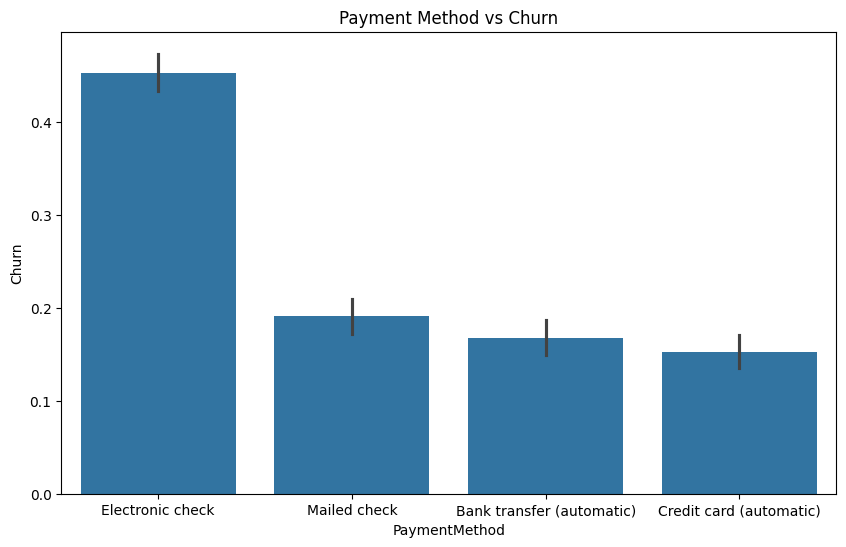

In [19]:
plt.figure( figsize=(10,6))
sns.barplot(x="PaymentMethod",y="Churn",data=df  )
plt.title("Payment Method vs Churn")

# making new features Payment Risk

In [20]:
df["PaymentRisk"]=df["PaymentMethod"].map({
    "Electronic check":2,
    "Mailed check":1,
    'Bank transfer (automatic)': 0,
    'Credit card (automatic)': 0
})

# Making new features LoyaltyScore

In [21]:
df['LoyaltyScore'] = df['tenure'] + df['ServicesUsed']


In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,ExpectedTotal,Billing_error,ServicesUsed,costPressure,FamilyScore,EarlyChurnRisk,StreamingUser,Frustration,PaymentRisk,LoyaltyScore
0,7590-VHVEG,Female,0,1,0,1,No,No phone service,DSL,0,...,29.85,0,1,0.531612,1,0.920044,0,0,2,2
1,5575-GNVDE,Male,0,0,0,34,Yes,No,DSL,1,...,1936.30,1,2,1.014248,0,0.058816,0,0,1,36
2,3668-QPYBK,Male,0,0,0,2,Yes,No,DSL,1,...,107.70,0,2,0.959038,0,0.846482,0,0,1,4
3,7795-CFOCW,Male,0,0,0,45,No,No phone service,DSL,1,...,1903.50,1,3,0.753339,0,0.023518,0,0,0,48
4,9237-HQITU,Female,0,0,0,2,Yes,No,Fiber optic,0,...,141.40,1,0,0.771203,0,0.846482,0,0,2,2


# Marking Contract  Types to 2,1,0

In [23]:

df["ContractType"]=df["Contract"].map({
    "Month-to-month":0,"One year":1,"Two year":2
})

In [24]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Billing_error,ServicesUsed,costPressure,FamilyScore,EarlyChurnRisk,StreamingUser,Frustration,PaymentRisk,LoyaltyScore,ContractType
0,7590-VHVEG,Female,0,1,0,1,No,No phone service,DSL,0,...,0,1,0.531612,1,0.920044,0,0,2,2,0
1,5575-GNVDE,Male,0,0,0,34,Yes,No,DSL,1,...,1,2,1.014248,0,0.058816,0,0,1,36,1
2,3668-QPYBK,Male,0,0,0,2,Yes,No,DSL,1,...,0,2,0.959038,0,0.846482,0,0,1,4,0
3,7795-CFOCW,Male,0,0,0,45,No,No phone service,DSL,1,...,1,3,0.753339,0,0.023518,0,0,0,48,1
4,9237-HQITU,Female,0,0,0,2,Yes,No,Fiber optic,0,...,1,0,0.771203,0,0.846482,0,0,2,2,0


In [25]:
pd.set_option('display.max_columns', None)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   int64   
 4   Dependents        7043 non-null   int64   
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   int64   
 10  OnlineBackup      7043 non-null   int64   
 11  DeviceProtection  7043 non-null   int64   
 12  TechSupport       7043 non-null   int64   
 13  StreamingTV       7043 non-null   int64   
 14  StreamingMovies   7043 non-null   int64   
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [26]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


# Making new Fetures FibercostRatio

In [27]:
fiber_avg = df.groupby('InternetService')['MonthlyCharges'].transform('mean')
df['FiberCostRatio'] = df['MonthlyCharges'] / fiber_avg

In [28]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,ExpectedTotal,Billing_error,ServicesUsed,costPressure,FamilyScore,EarlyChurnRisk,StreamingUser,Frustration,PaymentRisk,LoyaltyScore,ContractType,FiberCostRatio
0,7590-VHVEG,Female,0,1,0,1,No,No phone service,DSL,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6,29.85,0,1,0.531612,1,0.920044,0,0,2,2,0,0.513750
1,5575-GNVDE,Male,0,0,0,34,Yes,No,DSL,1,0,1,0,0,0,One year,No,Mailed check,56.95,1889.50,0,24-48,1936.30,1,2,1.014248,0,0.058816,0,0,1,36,1,0.980170
2,3668-QPYBK,Male,0,0,0,2,Yes,No,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6,107.70,0,2,0.959038,0,0.846482,0,0,1,4,0,0.926816
3,7795-CFOCW,Male,0,0,0,45,No,No phone service,DSL,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-48,1903.50,1,3,0.753339,0,0.023518,0,0,0,48,1,0.728028
4,9237-HQITU,Female,0,0,0,2,Yes,No,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-6,141.40,1,0,0.771203,0,0.846482,0,0,2,2,0,0.772677


# Choosing best Features on bases of Correlation Heat map

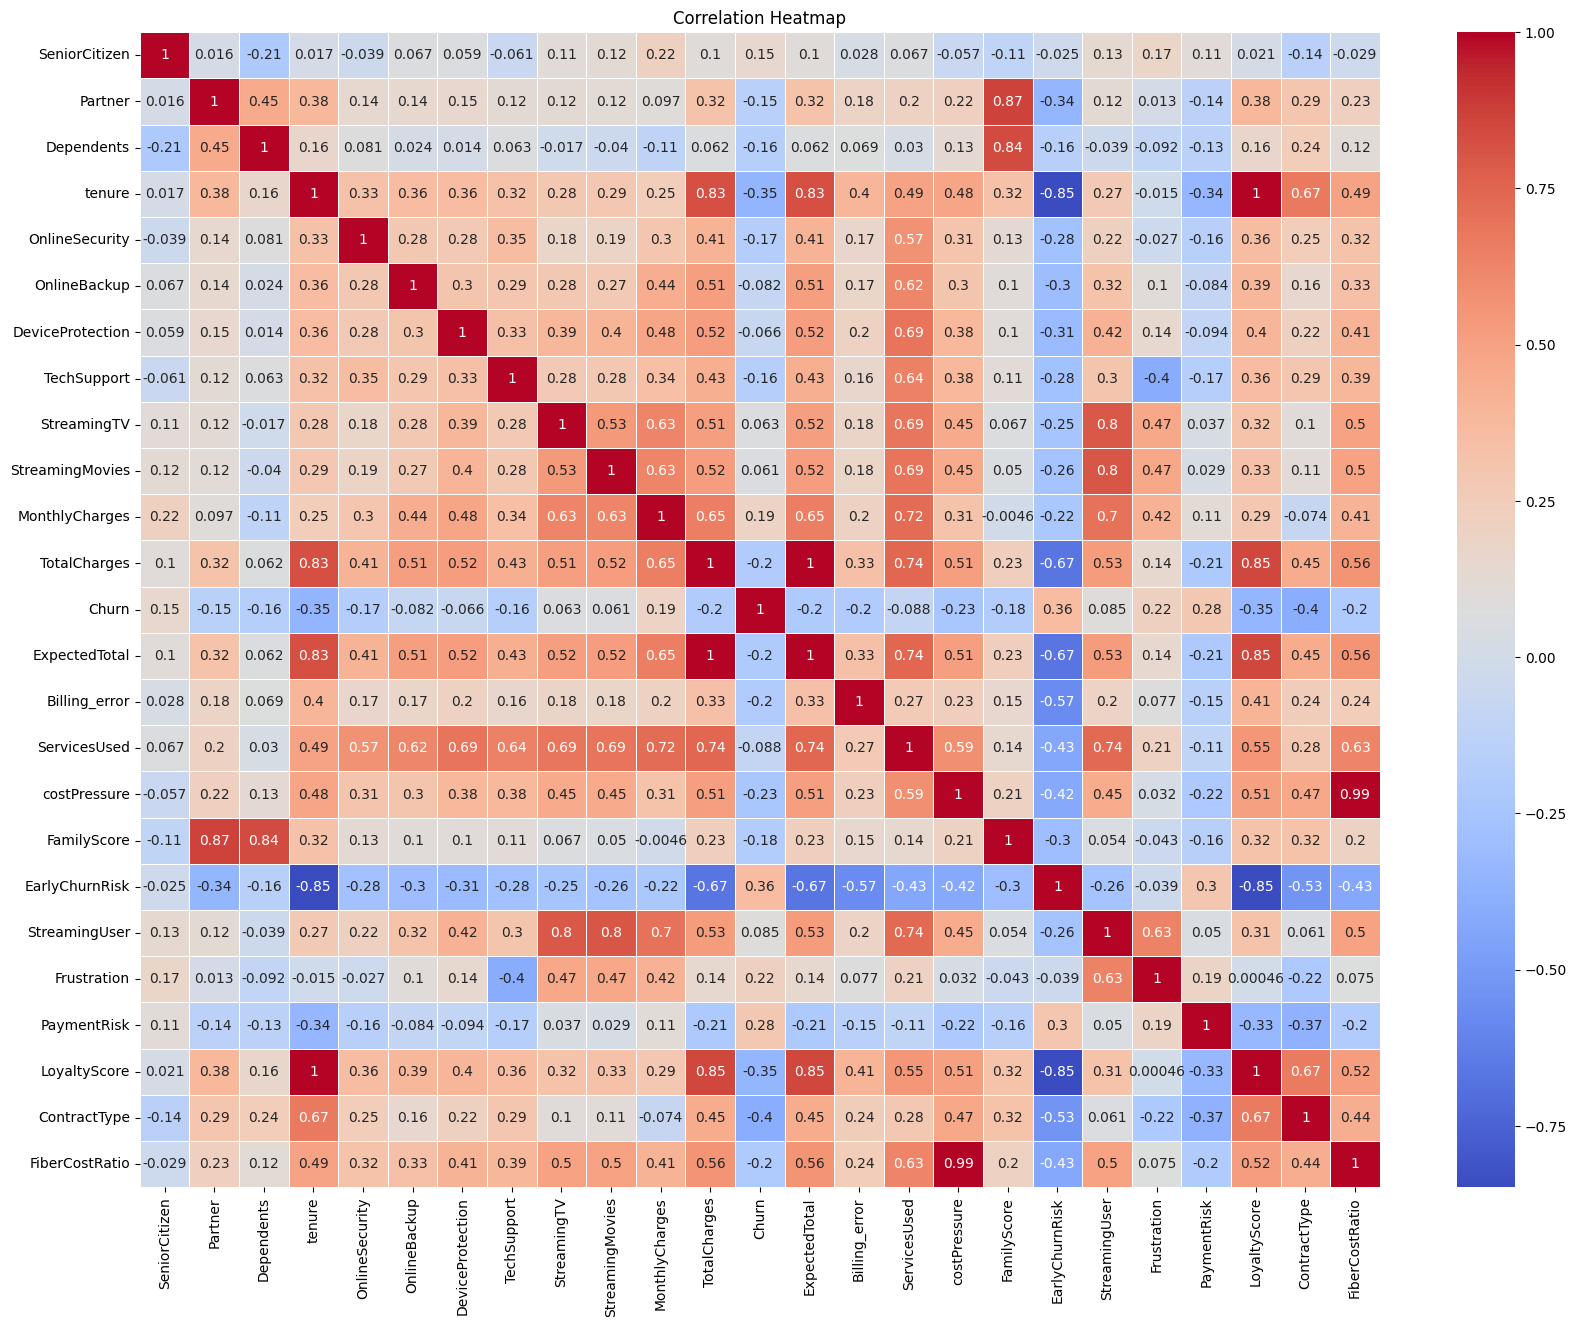

In [29]:
numeric_df=df.select_dtypes(["int64","float64"])
plt.figure(figsize=(20,15))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
print(numeric_df.corr()['Churn'].sort_values(ascending=False))


Churn               1.000000
EarlyChurnRisk      0.363836
PaymentRisk         0.282708
Frustration         0.219790
MonthlyCharges      0.193356
SeniorCitizen       0.150889
StreamingUser       0.085200
StreamingTV         0.063228
StreamingMovies     0.061382
DeviceProtection   -0.066160
OnlineBackup       -0.082255
ServicesUsed       -0.087698
Partner            -0.150448
Dependents         -0.164221
TechSupport        -0.164674
OnlineSecurity     -0.171226
FamilyScore        -0.184193
Billing_error      -0.196977
TotalCharges       -0.198324
ExpectedTotal      -0.198514
FiberCostRatio     -0.203765
costPressure       -0.234685
LoyaltyScore       -0.345276
tenure             -0.352229
ContractType       -0.396713
Name: Churn, dtype: float64


# Choosing best Features on bases of Mutual Information Score

In [31]:

num_cols = df.select_dtypes(include=np.number).columns.drop('Churn')
X_mi = df[num_cols]
y_mi = df['Churn']
X_mi = X_mi.replace([np.inf, -np.inf], np.nan)
X_mi = X_mi.fillna(0)

mi = mutual_info_classif(X_mi, y_mi)

mi_scores = pd.Series(mi, index=num_cols).sort_values(ascending=False)

print(mi_scores)

ContractType        0.100016
EarlyChurnRisk      0.077819
tenure              0.072852
costPressure        0.071102
LoyaltyScore        0.071053
FiberCostRatio      0.059763
ExpectedTotal       0.052270
PaymentRisk         0.048555
TotalCharges        0.044210
MonthlyCharges      0.041535
ServicesUsed        0.031858
Frustration         0.026800
FamilyScore         0.018392
Billing_error       0.016684
TechSupport         0.016178
Dependents          0.013979
OnlineSecurity      0.012484
OnlineBackup        0.010911
SeniorCitizen       0.009534
StreamingUser       0.009239
Partner             0.007267
StreamingTV         0.005745
DeviceProtection    0.004641
StreamingMovies     0.004158
dtype: float64


# Ranhdom Forest Feature Importance

In [32]:
# Ranhdom Forest Feature Importance
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

X = pd.get_dummies(X, drop_first=True)

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(15))

MonthlyCharges                    0.090540
ExpectedTotal                     0.087241
TotalCharges                      0.084016
costPressure                      0.074903
FiberCostRatio                    0.074009
EarlyChurnRisk                    0.068025
tenure                            0.064270
LoyaltyScore                      0.059927
ContractType                      0.048686
InternetService_Fiber optic       0.034779
PaymentRisk                       0.023569
PaymentMethod_Electronic check    0.022127
ServicesUsed                      0.019316
PaperlessBilling_Yes              0.017373
FamilyScore                       0.017372
dtype: float64


In [33]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [34]:
selected_features = [
    'ContractType',      
    'costPressure',
    'EarlyChurnRisk',
    'tenure',
    'LoyaltyScore',
    'FiberCostRatio',
    'ExpectedTotal',
    'MonthlyCharges',
    'PaymentRisk',
    'TotalCharges'
]

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.800568   0.660900  0.510695  0.576169
1                  SVM  0.792761   0.654135  0.465241  0.543750
2                  KNN  0.760823   0.555556  0.494652  0.523338


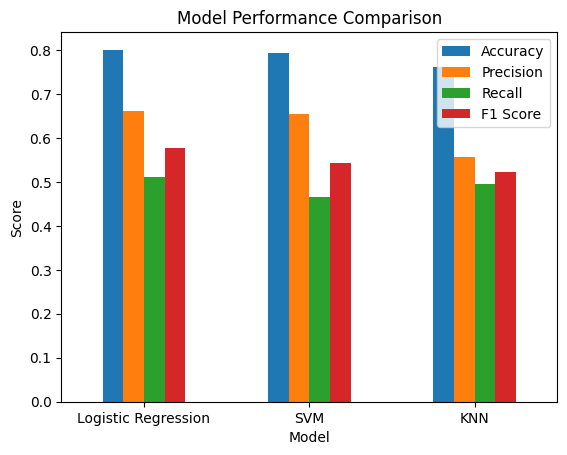

In [37]:
X = df[selected_features]
y = df['Churn']

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

metrics_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
)

print(metrics_df)

metrics_df.set_index('Model').plot(kind='bar')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()